In [430]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

In [431]:
import sklearn
from sklearn.decomposition import PCA

In [432]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [433]:
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

## 1/19 photon absorption

In [434]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_env_ene(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_freq = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        f = dd['fogi_frequency']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_freq.append(f)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_freq[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)-40):
                t = t + 15
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_freq, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

In [435]:
import os

In [445]:
header = "D:/K_sunada/result/CDY154/"
dirlist_tr = os.listdir(header + '/2024-01-24/')[15:35]
dirlist_utr = os.listdir(header + '/2024-01-24/')[39:59]
dirlist_sq = os.listdir(header + '/2024-01-24/')[59:79]

dirlist_sq1 = os.listdir(header + '/2024-01-20/')[84+3::]
dirlist_sq2 = os.listdir(header + '/2024-01-21/')[0::]

In [437]:
dirlist_sq

['2024-01-24T213448_f6a1d53b-78_JPA_ab_waveform_qstate_repeat',
 '2024-01-24T214128_e4f8b5da-78_JPA_ab_waveform_qstate_repeat',
 '2024-01-24T214805_d15965c9-78_JPA_ab_waveform_qstate_repeat',
 '2024-01-24T215447_c0db1fab-78_JPA_ab_waveform_qstate_repeat',
 '2024-01-24T220131_b205bacf-78_JPA_ab_waveform_qstate_repeat',
 '2024-01-24T220817_a3e4e1e9-78_JPA_ab_waveform_qstate_repeat',
 '2024-01-24T221503_95875617-78_JPA_ab_waveform_qstate_repeat',
 '2024-01-24T222149_8795597c-78_JPA_ab_waveform_qstate_repeat',
 '2024-01-24T222835_7a06e857-78_JPA_ab_waveform_qstate_repeat',
 '2024-01-24T223522_6c7ff6aa-78_JPA_ab_waveform_qstate_repeat',
 '2024-01-24T224210_5f5cf3de-78_JPA_ab_waveform_qstate_repeat',
 '2024-01-24T224857_51fe4ec7-78_JPA_ab_waveform_qstate_repeat',
 '2024-01-24T225541_4317f040-78_JPA_ab_waveform_qstate_repeat',
 '2024-01-24T230224_32f9f4d3-78_JPA_ab_waveform_qstate_repeat',
 '2024-01-24T230913_26aaf205-78_JPA_ab_waveform_qstate_repeat',
 '2024-01-24T231602_1a7b81d7-78_JPA_ab_w

[3.12121453e-07]


<Figure size 800x300 with 0 Axes>

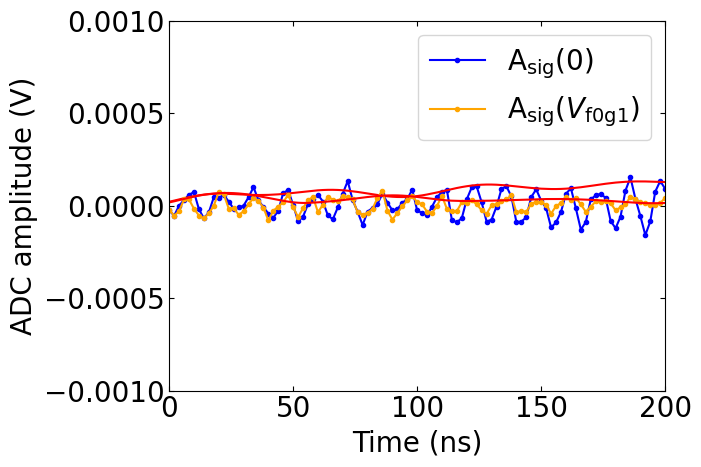

In [470]:
## absorption rate
ph_amp = 0
fogi_freq = 0
###############################################
data = dirlist_tr[0]
num_of_ph_amp = 8
num_of_fogi_freq = 1
###############################################
d = data_acquisition_env_ene(header+ '/2024-01-24/', data,num_of_ph_amp, num_of_fogi_freq, 78.89e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"A${_\mathrm{sig}}$(0)")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"A${_\mathrm{sig}(V_\mathrm{f0g1}}$)")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.001, 0.001)
ax0.set_xlim(0, 200)
plt.legend()
print(d[4][ph_amp])
# plt.tight_layout()
# plt.savefig('sekisan21_tr_07.png', bbox_inches='tight')
# plt.show()

67.87349865745568


<Figure size 800x300 with 0 Axes>

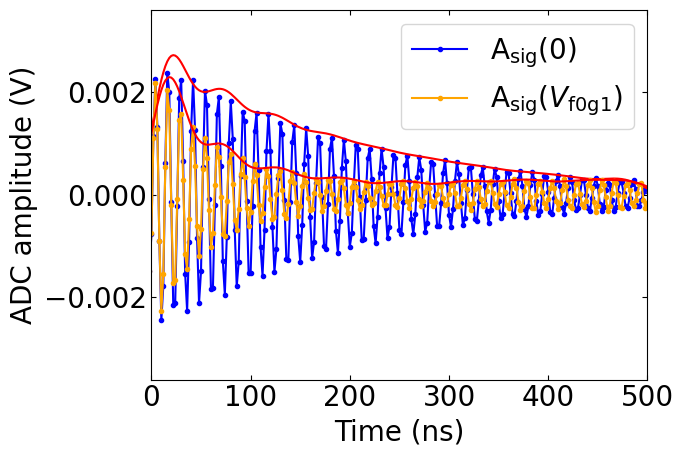

In [411]:
## absorption rate
ph_amp = 7
fogi_freq = 0
###############################################
data = dirlist_utr[0]
num_of_ph_amp = 8
num_of_fogi_freq = 1
###############################################
d = data_acquisition_env_ene(header+ '/2024-01-24/', data,num_of_ph_amp, num_of_fogi_freq, 78.89e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"A${_\mathrm{sig}}$(0)")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"A${_\mathrm{sig}(V_\mathrm{f0g1}}$)")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0036, 0.0036)
ax0.set_xlim(0, 500)
print(ab_rate)
plt.legend()
# # plt.tight_layout()
# plt.savefig('sekisan21_utr_07.png', bbox_inches='tight')
plt.show()

<Figure size 800x300 with 0 Axes>

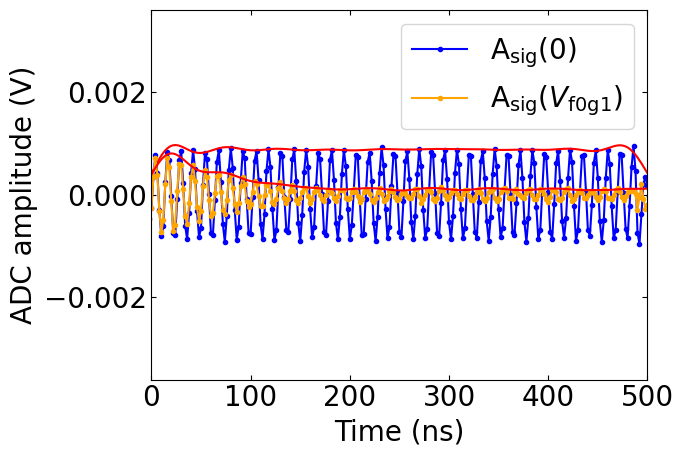

In [412]:
## absorption rate
ph_amp = 7
fogi_freq = 0
###############################################
data = dirlist_sq[0]
num_of_ph_amp = 8
num_of_fogi_freq = 1
###############################################
d = data_acquisition_env_ene(header+ '/2024-01-24/', data,num_of_ph_amp, num_of_fogi_freq, 78.89e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"A${_\mathrm{sig}}$(0)")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"A${_\mathrm{sig}(V_\mathrm{f0g1}}$)")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0036, 0.0036)
ax0.set_xlim(0, 500)
plt.legend()
# plt.tight_layout()
# plt.savefig('sekisan21_sq_07.png', bbox_inches='tight')
plt.show()

In [446]:
##tr
tr_rate_003 = []
tr_rate_01 = []
tr_rate_02 = []
tr_rate_03 = []
tr_rate_04 = []
tr_rate_05 = []
tr_rate_06 = []
tr_rate_07 = []
for i in range(len(dirlist_tr)):
    data = dirlist_tr[i]
    num_of_ph_amp = 8
    num_of_fogi_freq = 1
    ###############################################
    d = data_acquisition_env_ene(header+'/2024-01-24/', data,num_of_ph_amp, num_of_fogi_freq, 78.89e6)
    rate_003 = d[5][0][0]
    rate_01 = d[5][1][0]
    rate_02 = d[5][2][0]
    rate_03 = d[5][3][0]
    rate_04 = d[5][4][0]
    rate_05 = d[5][5][0]
    rate_06 = d[5][6][0]
    rate_07 = d[5][7][0]
    tr_rate_003.append(rate_003)
    tr_rate_01.append(rate_01)
    tr_rate_02.append(rate_02)
    tr_rate_03.append(rate_03)
    tr_rate_04.append(rate_04)
    tr_rate_05.append(rate_05)
    tr_rate_06.append(rate_06)
    tr_rate_07.append(rate_07)

tr_rates = np.array([tr_rate_003, tr_rate_01, tr_rate_02, tr_rate_03, tr_rate_04, tr_rate_05, tr_rate_06, tr_rate_07])

In [447]:
##utr
utr_rate_003 = []
utr_rate_01 = []
utr_rate_02 = []
utr_rate_03 = []
utr_rate_04 = []
utr_rate_05 = []
utr_rate_06 = []
utr_rate_07 = []
for i in range(len(dirlist_utr)):
    data = dirlist_utr[i]
    num_of_ph_amp = 8
    num_of_fogi_freq = 1
    ###############################################
    d = data_acquisition_env_ene(header+'/2024-01-24/', data,num_of_ph_amp, num_of_fogi_freq, 78.89e6)
    rate_003 = d[5][0][0]
    rate_01 = d[5][1][0]
    rate_02 = d[5][2][0]
    rate_03 = d[5][3][0]
    rate_04 = d[5][4][0]
    rate_05 = d[5][5][0]
    rate_06 = d[5][6][0]
    rate_07 = d[5][7][0]
    utr_rate_003.append(rate_003)
    utr_rate_01.append(rate_01)
    utr_rate_02.append(rate_02)
    utr_rate_03.append(rate_03)
    utr_rate_04.append(rate_04)
    utr_rate_05.append(rate_05)
    utr_rate_06.append(rate_06)
    utr_rate_07.append(rate_07)

utr_rates = np.array([utr_rate_003, utr_rate_01, utr_rate_02, utr_rate_03, utr_rate_04, utr_rate_05, utr_rate_06, utr_rate_07])

In [448]:
##sq
sq_rate_003 = []
sq_rate_01 = []
sq_rate_02 = []
sq_rate_03 = []
sq_rate_04 = []
sq_rate_05 = []
sq_rate_06 = []
sq_rate_07 = []
for i in range(len(dirlist_sq)-1):
    data = dirlist_sq[i]
    num_of_ph_amp = 8
    num_of_fogi_freq = 1
    ###############################################
    d = data_acquisition_env_ene(header+'/2024-01-24/', data,num_of_ph_amp, num_of_fogi_freq, 78.89e6)
    rate_003 = d[5][0][0]
    rate_01 = d[5][1][0]
    rate_02 = d[5][2][0]
    rate_03 = d[5][3][0]
    rate_04 = d[5][4][0]
    rate_05 = d[5][5][0]
    rate_06 = d[5][6][0]
    rate_07 = d[5][7][0]
    sq_rate_003.append(rate_003)
    sq_rate_01.append(rate_01)
    sq_rate_02.append(rate_02)
    sq_rate_03.append(rate_03)
    sq_rate_04.append(rate_04)
    sq_rate_05.append(rate_05)
    sq_rate_06.append(rate_06)
    sq_rate_07.append(rate_07)



sq_rates = np.array([sq_rate_003, sq_rate_01, sq_rate_02, sq_rate_03, sq_rate_04, sq_rate_05, sq_rate_06, sq_rate_07])

In [449]:
def error_bar(rate):
    rate_mean = np.mean(rate)
    rate_se = np.array(np.std(rate))
    return rate_mean, rate_se

In [450]:
tr_data_m = []
tr_data_s = []
for i in range(len(tr_rates)):
    rate_mean = error_bar(tr_rates[i])[0]
    rate_se = error_bar(tr_rates[i])[1]
    tr_data_m.append(rate_mean)
    tr_data_s.append(rate_se)
tr_data = [tr_data_m, tr_data_s]

utr_data_m = []
utr_data_s = []
for i in range(len(utr_rates)):
    rate_mean = error_bar(utr_rates[i])[0]
    rate_se = error_bar(utr_rates[i])[1]
    utr_data_m.append(rate_mean)
    utr_data_s.append(rate_se)
utr_data = [utr_data_m, utr_data_s]

sq_data_m = []
sq_data_s = []
for i in range(len(sq_rates)):
    rate_mean = error_bar(sq_rates[i])[0]
    rate_se = error_bar(sq_rates[i])[1]
    sq_data_m.append(rate_mean)
    sq_data_s.append(rate_se)
sq_data = [sq_data_m, sq_data_s]

In [451]:
utr_rate_04, tr_data[1]

([69.42453155506739,
  69.79048153523357,
  69.29720251670899,
  70.18917005674655,
  69.43393926981216,
  69.84331760642668,
  69.46617685021626,
  70.25319602273076,
  70.25213471187946,
  69.0131850044563,
  69.04144734444483,
  68.97870246318611,
  69.80232117830086,
  70.32238415777462,
  69.98365712056297,
  69.04248624844776,
  70.59615658159342,
  70.58160076522218,
  70.7804002059693,
  71.1964723373551],
 [array(0.47231494),
  array(0.64571452),
  array(0.9583177),
  array(0.81862001),
  array(1.33066921),
  array(1.247527),
  array(1.27643877),
  array(1.24974972)])

In [452]:
tr_data[1]

[array(0.47231494),
 array(0.64571452),
 array(0.9583177),
 array(0.81862001),
 array(1.33066921),
 array(1.247527),
 array(1.27643877),
 array(1.24974972)]

[97.9125424114977, 96.56429315477565, 94.26269022315456, 91.0080527659854, 87.78336828940546, 84.33400081729266, 80.93269152277594, 77.64306353638958]


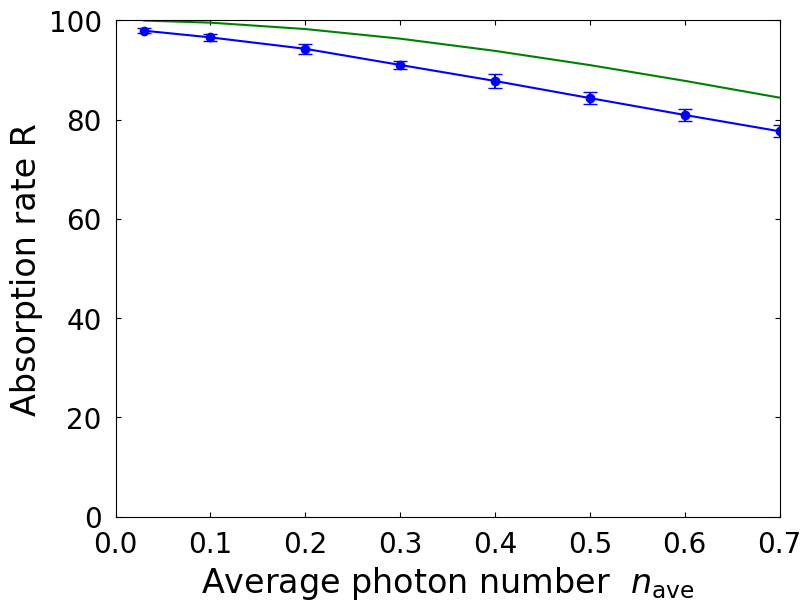

In [471]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(pad = 10,top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

ph_num = np.array([0.03, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
ax.plot(ph_num, tr_data[0], 'o', color='blue')
x = np.array([0.03, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
ax.plot(x, np.exp(-x)*(1+x)*100, label="Theory", color = "green")
# ax.plot(ph_num, utr_data[0], 'o', color='orange')
# ax.plot(ph_num, sq_data[0], 'o',color='green')
# ax.plot(ph_num, 1-np.exp(-ph_num)*(ph_num+ph_num**2))
ax.errorbar(ph_num, tr_data[0], yerr=tr_data[1],  capsize=5, label="Rising exponential pulse", color='blue')
# ax.errorbar(ph_num, utr_data[0], yerr=utr_data[1], capsize=5, label="Decaying exponential pulse",color='orange')
# ax.errorbar(ph_num, sq_data[0], yerr=sq_data[1],  capsize=5, label="Square pulse", color='green')
ax.set_xlabel('Average photon number  $n_{\mathrm{ave}}$', size='large')
ax.set_ylabel('Absorption rate R', size='large')
# plt.legend()
plt.ylim(0, 100)
plt.xlim(0, 0.7)
print(tr_data[0])
# plt.savefig('abs_rate_summary_defence1.png', bbox_inches='tight')


In [123]:
tr_amp = [0.282, 0.515, 0.728, 0.891, 1.029, 1.151, 1.261, 1.362]
sq_amp = [0.338, 0.617, 0.872, 1.068, 1.233, 1.379, 1.511, 1.631]
abs_rate =np.array(tr_data[0])*1e-2

In [126]:
def square(freq, amp, duration):
    x = np.linspace(0, duration-1, duration)
    y = amp* np.cos(2*np.pi* freq*(x*1e-9))
    env = np.zeros(duration) + amp
    return y, env

3.3252012500000075e-09 1.7140725393001967e-09 51.54793380701974


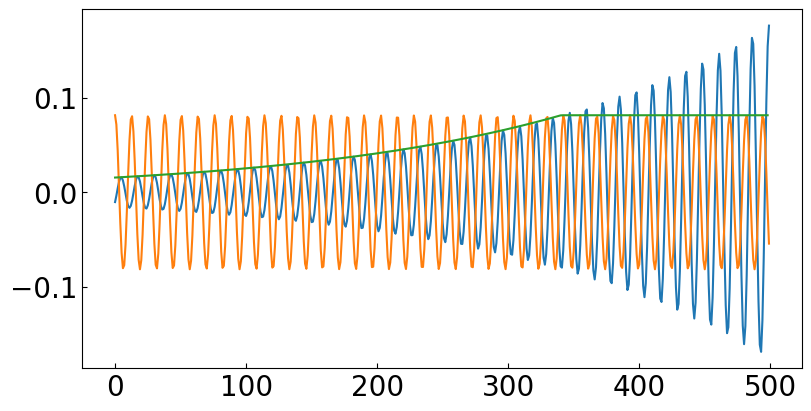

In [153]:
# square simulation
id = 4
amp_id = 7
sample_rate = 2e-9
ph_if = [74.04e6, 77.88e6, 78.85e6, 78.85e6, 78.89e6, 80.00e6, 75.71e6, 80.00e6, 85.00e6]
amp = [5.0130e-04, 8.1523e-04, 0.00122458, 0.00150458, 0.00215715, 0.00246627, 0.00290790, 0.00604601]
gamma = [0.00147027, 0.00264687, 0.00458680, 0.00656348, 0.00972759	, 0.01271420, 0.01645340, 0.02609383]
x = np.linspace(0, 499, 500)
y_env = amp[id]*np.exp(-(gamma[id]/2)*(x+26))*1e2
tr_waveform_if = (y_env*np.cos(2*np.pi* ph_if[id]*(x*1e-9)))[::-1]*tr_amp[amp_id] * abs_rate[amp_id]
tr_waveform = (y_env)[::-1]*tr_amp[amp_id]
tr_waveform_abs = tr_waveform * abs_rate[amp_id] ## abs limit
fig, ax = plt.subplots(figsize=(8,4),constrained_layout=True)
sq_waveform_if = np.array(square(ph_if[4], 0.05, 500)[0] )*sq_amp[amp_id]
sq_waveform = np.array(square(ph_if[4], 0.05, 500)[1] )*sq_amp[amp_id]

ene_org = 0
for t in range(int(len(x)/sample_rate*1e-9)+1):
    y = sq_waveform[2*t]
    ene_org = ene_org + (y**2)*sample_rate

ys = []
ene_abs = 0
for t in range(int(len(x)/sample_rate*1e-9)+1):
    if tr_waveform_abs[2*t]<sq_waveform[2*t]:
        y = tr_waveform_abs[2*t]
        ys.append(y)
    else:
        y = sq_waveform[2*t]
        ys.append(y)
    ene_abs = ene_abs + (y**2)*sample_rate

# plt.plot(x, tr_waveform)
plt.plot(x, tr_waveform_if)
plt.plot(x, sq_waveform_if)
plt.plot(np.linspace(0, 498, 250), ys)
print(ene_org, ene_abs, ene_abs/ene_org*1e2)

In [ ]:
sim_sq_rate = [64.36, 63.31, 61.58, 59.70, 57.68, 54.93, 53.09, 51.55]

6.904314684780152e-09 7.507707125106972e-10 10.87393531128721


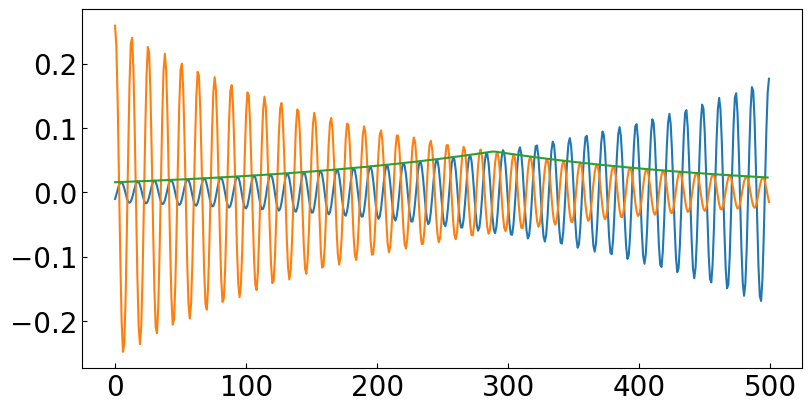

In [164]:
# utr simulation
id = 4
amp_id = 7
sample_rate = 2e-9
ph_if = [74.04e6, 77.88e6, 78.85e6, 78.85e6, 78.89e6, 80.00e6, 75.71e6, 80.00e6, 85.00e6]
amp = [5.0130e-04, 8.1523e-04, 0.00122458, 0.00150458, 0.00215715, 0.00246627, 0.00290790, 0.00604601]
gamma = [0.00147027, 0.00264687, 0.00458680, 0.00656348, 0.00972759	, 0.01271420, 0.01645340, 0.02609383]
x = np.linspace(0, 499, 500)
y_env = amp[id]*np.exp(-(gamma[id]/2)*(x+26))*1e2
tr_waveform_if = (y_env*np.cos(2*np.pi* ph_if[id]*(x*1e-9)))[::-1]*tr_amp[amp_id] * abs_rate[amp_id]
tr_waveform = (y_env)[::-1]*tr_amp[amp_id]
tr_waveform_abs = tr_waveform * abs_rate[amp_id] ## abs limit
fig, ax = plt.subplots(figsize=(8,4),constrained_layout=True)
utr_waveform_if = (y_env*np.cos(2*np.pi* ph_if[id]*(x*1e-9)))*tr_amp[amp_id] 
utr_waveform = (y_env)*tr_amp[amp_id]

ene_org = 0
for t in range(int(len(x)/sample_rate*1e-9)+1):
    y = utr_waveform[2*t]
    ene_org = ene_org + (y**2)*sample_rate

ys = []
ene_abs = 0
for t in range(int(len(x)/sample_rate*1e-9)+1):
    if tr_waveform_abs[2*t]<utr_waveform[2*t]:
        y = tr_waveform_abs[2*t]
        ys.append(y)
    else:
        y = utr_waveform[2*t]
        ys.append(y)
    ene_abs = ene_abs + (y**2)*sample_rate

# plt.plot(x, tr_waveform)
plt.plot(x, tr_waveform_if)
plt.plot(x, utr_waveform_if)
plt.plot(np.linspace(0, 498, 250), ys)
print(ene_org, ene_abs, ene_abs/ene_org*1e2)

In [ ]:
sim_utr_rate = [15.23, 14.805, 14.14, 13.47, 12.78, 11.89, 11.33, 10.87]